# Assignment - classification

Hi there! In this assignment, you will use a fully connected neural network (FCNN) to solve an adapted Question 1 of the winter 2023 exam in applied machine learning:

As in Assignment 1, the primary objective of this exam is to perform image classification using the PCam dataset. For a detailed description of the dataset, please refer to the assignment 1 description. The assignment is posted as a Kaggle competition and is available here: https://www.kaggle.com/t/c3f87171d2f543c38155fdfb33a6c9b0

To get you started, I have provided a complete working example, which is decent but not very impressive.

When you are done, submit your results on the Kaggle webpage for this competition. If you do not like to show your score to everyone, you may use an anonymous username on Kaggle.

However, I suggest you use your real name, after all it is just meant as an exercise and it is more fun that way. You can submit 5 times every day, so you can experiment with some stuff without being "locked in".

# Details

The metric used to score this assignment is accuracy (as in the first assignment).

### Question (adapted from the exam):
Use FCNN to perform image classification (tumor detection). Consider among other things the following:
1. Different activation functions
2. Different number of layers
3. Different number of neurons in each layer
4. Different learning rates
5. Different batch sizes
6. Different number of epochs
7. Different optimizers

**Note:** When you do hyperparameter tuning, you should use the validation set. The test set should only be used for the final evaluation.


# Hints to get you started (with a very simple model)

In [1]:
import tensorflow as tf
from tensorflow.keras.optimizers import SGD
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import keras # Ensure Keras is imported
tf.config.set_visible_devices([], 'GPU')

Defining a function that takes a (None,96,96,3) array and turn it into (None, 32,32,1) (grayscale, resize and normalize). This function might also become handy if the original images are too large for your hardware configuration.

In [3]:
def resize_and_normalize_image(image):
    image = tf.image.resize(image,[32,32])
    #image = tf.image.rgb_to_grayscale(image)
    return image / 255.0

def convert_sample(data):

    # Create a TensorFlow dataset from the training data features
    dataset = tf.data.Dataset.from_tensor_slices(data)

    # Define a function to resize each image in the dataset

    # Apply the resize function to each image in the dataset
    resized_dataset = dataset.map(resize_and_normalize_image)

    # Convert the resized dataset to a NumPy array
    resized_arr = np.array(list(resized_dataset.as_numpy_iterator()))

    return resized_arr

In [4]:
# Load the training data features
X_train_raw = np.load('Xtrain.npy')
print(f'Shape of the raw training data: {X_train_raw.shape}')
X_test_raw = np.load('Xtest.npy')
print(f'Shape of the raw test data: {X_test_raw.shape}')

X_train_converted = convert_sample(X_train_raw)
print(f'Shape the resized training data: {X_train_converted.shape}')

X_test_converted = convert_sample(X_test_raw)
print(f'Shape the resized test data: {X_test_converted.shape}')

y_train_raw = np.load('ytrain.npy')
#y_train_reshaped = y_train.reshape(-1,1) 
print(f'Shape of the raw labels: {y_train_raw.shape}')


Shape of the raw training data: (26214, 96, 96, 3)
Shape of the raw test data: (1638, 96, 96, 3)


2025-10-20 17:39:21.688657: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Shape the resized training data: (26214, 32, 32, 3)
Shape the resized test data: (1638, 32, 32, 3)
Shape of the raw labels: (26214,)


2025-10-20 17:39:21.967590: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
#Apply PCA to X_train and X_test
from sklearn.decomposition import PCA

# --- Step 1.1: Reshape/Flatten ---
# Flatten the spatial dimensions for both train and test sets
X_train_flat = X_train_converted.reshape(X_train_converted.shape[0], -1)
X_test_flat = X_test_converted.reshape(X_test_converted.shape[0], -1)

# --- Step 1.2: Standardize (Fit on Train, Transform on Both) ---
# Initialize the scaler
scaler = StandardScaler()

# 1. FIT on the TRAINING data ONLY
X_train_scaled = scaler.fit_transform(X_train_flat)

# 2. TRANSFORM the TEST data using the *fitted* scaler
X_test_scaled = scaler.transform(X_test_flat)

print(f"Standardized X_train shape: {X_train_scaled.shape}")
print(f"Standardized X_test shape: {X_test_scaled.shape}")

n_components = 0.6
pca = PCA(n_components=n_components)

pca.fit(X_train_scaled)

print(f"\nPCA components determined: {pca.n_components_}")
print(f"Total variance explained: {np.sum(pca.explained_variance_ratio_):.4f}")


# --- Step 2.3: Transform Both Sets ---
# Use the *fitted* PCA model to project BOTH datasets into the new feature space
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nFinal X_train_pca shape: {X_train_pca.shape}")
print(f"Final X_test_pca shape: {X_test_pca.shape}")

Standardized X_train shape: (26214, 3072)
Standardized X_test shape: (1638, 3072)

PCA components determined: 172
Total variance explained: 0.6001

Final X_train_pca shape: (26214, 172)
Final X_test_pca shape: (1638, 172)


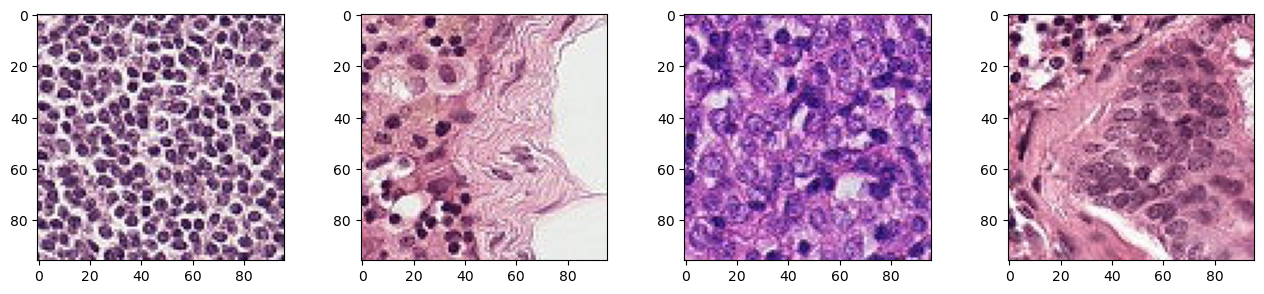

In [209]:
# Check the images
fig = plt.figure(figsize=plt.figaspect(0.2))

ax = fig.add_subplot(1, 4, 1)
plt.imshow(X_train[0], cmap='gray')

ax = fig.add_subplot(1, 4, 2)
plt.imshow(X_train[1], cmap='gray')

ax = fig.add_subplot(1, 4, 3)
plt.imshow(X_train[2], cmap='gray')

ax = fig.add_subplot(1, 4, 4)
plt.imshow(X_train[400], cmap='gray')

In [9]:
n = 20000
from sklearn.model_selection import train_test_split

random_indices = np.random.choice(X_train_pca.shape[0], n, replace=False)

# Subset X and y using the random indices
X_subset = X_train_pca[random_indices]
y_subset = y_train_raw[random_indices]

#Split into training & validation data
X_val, X_train, y_val, y_train = train_test_split(X_subset, y_subset, train_size=0.3, random_state=8)
X_train.shape, X_val.shape, y_train.shape, y_val.shape


((14000, 172), (6000, 172), (14000,), (6000,))

In [15]:
#Split into train and validation data
from sklearn.model_selection import train_test_split

#X_train, X_val, y_train, y_val = train_test_split(X_train_pca, y_train_raw, test_size=0.3)
X_train, X_val, y_train, y_val = train_test_split(X_train_converted, y_train_raw, test_size=0.2)

#print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

In [14]:
def build_model(activation, first_layer_nodes, second_layer_nodes):
    model = tf.keras.models.Sequential([
    tf.keras.layers.Input((172,)),
    tf.keras.layers.Dense(first_layer_nodes, activation=activation),
    tf.keras.layers.Dropout(rate=0.4),
    tf.keras.layers.Dense(second_layer_nodes, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax'),
    ])
    return model

In [16]:
#Check each base optimizer to find the best activation function
optimizers = ['SGD', 'Adam', 'Adagrad', 'Adadelta', 'RMSProp']
activations = ['sigmoid', 'mish', 'silu']
layer_nodes = [800, 1000]

results = []

for optimizer in optimizers:
    for activation in activations:
        for first_layer_nodes in layer_nodes:
            for second_layer_nodes in layer_nodes:
                nn_sgd = build_model(activation, first_layer_nodes, second_layer_nodes)
                nn_sgd.compile(
                    optimizer=optimizer,
                    loss='sparse_categorical_crossentropy', 
                    metrics=['accuracy']
                    )
                nn_sgd.fit(X_train, y_train, epochs=10)
                acc = nn_sgd.evaluate(X_val, y_val)[1]
                print(f'Test accuracy with optimizer SGD = {round(acc, 3)}%')
                results.append([activation, optimizer, first_layer_nodes, second_layer_nodes, acc])
        
cols=["Activation function", "Optimizer", "First layer nodes", "Second layer nodes", "Accuracy"]
sgd_results_df = pd.DataFrame(results, columns=cols)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6521 - loss: 0.6263   
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6931 - loss: 0.5886
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7025 - loss: 0.5731
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7071 - loss: 0.5707
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7149 - loss: 0.5605
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7181 - loss: 0.5565
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7186 - loss: 0.5536
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7227 - loss: 0.5516
Epoch 9/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7264 - loss: 0.5482
Epoch 10/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7299 - loss: 0.5430 
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.6332 - loss: 0.7170
Test accuracy with optimizer SGD = 0.633%
Epoch 1/10
438/4

In [20]:
sgd_results_df.sort_values('Accuracy')

,Activation function,Optimizer,First layer nodes,Second layer nodes,Accuracy
2,sigmoid,SGD,1000,800,0.590833
3,sigmoid,SGD,1000,1000,0.627500
0,sigmoid,SGD,800,800,0.633167
57,silu,RMSProp,800,1000,0.651500
53,mish,RMSProp,800,1000,0.657833
39,sigmoid,Adadelta,1000,1000,0.660167
40,mish,Adadelta,800,800,0.660833
58,silu,RMSProp,1000,800,0.660833
45,silu,Adadelta,800,1000,0.666000
47,silu,Adadelta,1000,1000,0.666167


In [267]:
#start by optimizing the SGD optimizer
activation_funcs = ['relu']
learning_rates = [0.0002]
momentums = [0.99]
nestorovs = [False]
emas = [True, False]
epochs = [5, 10]

results = []

for activation in activation_funcs:
    for l_r in learning_rates:
        for momentum in momentums:
            for nestorov in nestorovs:
                for em in emas:
                    for epoch in epochs:
                        custom_sgd = tf.keras.optimizers.SGD(
                            learning_rate=l_r,
                            momentum=momentum,
                            nesterov = nestorov,
                            use_ema=em
                        )
                        nn = build_model(activation)
                        nn.compile(
                            optimizer=custom_sgd,
                            loss='sparse_categorical_crossentropy', 
                            metrics=['accuracy']
                            )
                        nn.fit(X_train, y_train, epochs=epoch)
                        acc = nn.evaluate(X_val, y_val)[1]
                        print(f'Test accuracy with optimizer SGD = {round(acc, 3)}%')
                        results.append([activation, l_r, momentum, nestorov, em, epoch, acc])
            
cols=["Activation function", "learning rate", "Momentum", "Nesterov", "Ema", "Epochs", "Accuracy"]
sgd_results_df = pd.DataFrame(results, columns=cols)


Epoch 1/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.7043 - loss: 0.5968  
Epoch 2/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 856us/step - accuracy: 0.7456 - loss: 0.5281
Epoch 3/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - accuracy: 0.7638 - loss: 0.4994
Epoch 4/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - accuracy: 0.7748 - loss: 0.4839
Epoch 5/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step - accuracy: 0.7897 - loss: 0.4600
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.7510 - loss: 0.5124
Test accuracy with optimizer SGD = 0.751%
Epoch 1/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - accuracy: 0.6938 - loss: 0.6034  
Epoch 2/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - accuracy: 0.7451 - loss: 0.5245
Epoch 3/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - accuracy: 0.7586 - loss: 0.5067
Epoch 4/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - accuracy: 0.7721 - loss: 0.4871
Epoch 5/10
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step - accuracy: 0.7846 - loss: 0.4668
Ep

In [269]:
sgd_results_df.sort_values('Accuracy', ascending=False)

,Activation function,learning rate,Momentum,Nesterov,Ema,Epochs,Accuracy
2,relu,0.0002,0.99,False,False,5,0.758462
1,relu,0.0002,0.99,False,True,10,0.753654
0,relu,0.0002,0.99,False,True,5,0.750962
3,relu,0.0002,0.99,False,False,10,0.737308


**Best SGD optimizer**

Is learning_rate = 0.02, Momentum = 0.9, Nesterov = True with 71%

This is probably never going to come close to ADAM

In [36]:
epochs = range(30,50, 5)
layer_nodes = [300, 500, 800, 1000]

results = []

#Now make ADAM predictions and save to .csv file
for e in epochs:
    for first_layer_nodes in layer_nodes:
        for second_layer_nodes in layer_nodes:
            sgd_model = build_model('relu', first_layer_nodes, second_layer_nodes)
            best_sgd = tf.keras.optimizers.SGD(
                learning_rate=0.0002,
                momentum=0.99,
                nesterov = False,
                use_ema= True,
                weight_decay = 0.3
            )
            
            sgd_model.compile(
                optimizer=best_sgd,
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy']
            )
            sgd_model.fit(X_train, y_train, epochs=e)
            val_acc = sgd_model.evaluate(X_val, y_val)[1]
            print(f'Validation accuracy with epochs {e} = {round(val_acc, 3)}%')
            results.append((e, first_layer_nodes, second_layer_nodes, val_acc))

cols = ["Epochs", "First layer nodes", "Second layer nodes", "Validation accuracy"]
adam_results_df = pd.DataFrame(results, columns=cols)
#y_test_hat_sgd = adam_model.predict(X_test_pca)
#y_test_hat_sgd_df = pd.DataFrame(y_test_hat_sgd, columns=["0", "1"])

"""
y_test_hat_ = np.argmax(y_test_hat, axis=1)

ytest_hat_pd = pd.DataFrame({
    'Id': list(range(len(y_test_hat))),
    'Predicted': y_test_hat.reshape(-1,),
})

"""
#y_test_hat_sgf_df.to_csv('y_test_hat_sgd.csv', index=False)

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - accuracy: 0.6352 - loss: 0.7298  
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.6934 - loss: 0.5870
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.7131 - loss: 0.5652
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step - accuracy: 0.7366 - loss: 0.5419
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - accuracy: 0.7481 - loss: 0.5241
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.7588 - loss: 0.5108
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step - accuracy: 0.7679 - loss: 0.4978
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - accuracy: 0.7780 - loss: 0.4789
Epoch 9/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - accuracy: 0.7852 - loss: 0.4641
Epoch 10/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - accuracy: 0.7953 - loss: 0.4488
Epoch 11/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.8067 - loss: 0.4351
Epoch 12/30
438/438 ━━━━━━━━

"\ny_test_hat_ = np.argmax(y_test_hat, axis=1)\n\nytest_hat_pd = pd.DataFrame({\n    'Id': list(range(len(y_test_hat))),\n    'Predicted': y_test_hat.reshape(-1,),\n})\n\n"

In [44]:
adam_results_df.sort_values('Validation accuracy', ascending=False)

,Epochs,First layer nodes,Second layer nodes,Validation accuracy
45,40,1000,500,0.742833
25,35,800,500,0.741167
28,35,1000,300,0.740500
47,40,1000,1000,0.740167
14,30,1000,800,0.738667
...,...,...,...,...
1,30,300,500,0.714667
2,30,300,800,0.714333
33,40,300,500,0.710667
19,35,300,1000,0.709167


In [48]:
#Now make SGD predictions and save to .csv file
#The best model had around 74% accuracy
sgd_model = build_model('relu', 1000, 500)
best_sgd = tf.keras.optimizers.SGD(
    learning_rate=0.0002,
    momentum=0.99,
    nesterov = False,
    use_ema= True,
    weight_decay = 0.3
)

sgd_model.compile(
    optimizer=best_sgd,
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
sgd_model.fit(X_train_pca, y_train_raw, epochs=40)

y_test_hat_sgd = sgd_model.predict(X_test_pca)
y_test_hat_sgd_df = pd.DataFrame(y_test_hat_sgd, columns=["0", "1"])

"""
y_test_hat_ = np.argmax(y_test_hat, axis=1)

ytest_hat_pd = pd.DataFrame({
    'Id': list(range(len(y_test_hat))),
    'Predicted': y_test_hat.reshape(-1,),
})

"""
y_test_hat_sgd_df.to_csv('y_test_hat_sgd.csv', index=False)

Epoch 1/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6703 - loss: 0.6517
Epoch 2/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7239 - loss: 0.5537
Epoch 3/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7485 - loss: 0.5234
Epoch 4/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7603 - loss: 0.5064
Epoch 5/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7718 - loss: 0.4872
Epoch 6/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7807 - loss: 0.4692
Epoch 7/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7940 - loss: 0.4513
Epoch 8/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8062 - loss: 0.4329
Epoch 9/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8188 - loss: 0.4103
Epoch 10/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8283 - loss: 0.3915
Epoch 11/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8402 - loss: 0.3739
Epoch 12/40
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

In [167]:
# optimizing the Adam optimizer
learning_rates = [0.001]
beta_1s = [0.43]
beta_2s = [0.93]
epsilons =[0.0000007]
emas = [True]
ema_momentums = [0.99]
weight_decays = [0.00005]

results = []

for l_r in learning_rates:
    for b1 in beta_1s:
        for b2 in beta_2s:
            for e in epsilons:
                for ema in emas:
                    for ema_momentum in ema_momentums:
                        for weight_decay in weight_decays:
                            custom_adam = tf.keras.optimizers.Adam(
                                learning_rate=l_r,
                                beta_1= b1,
                                beta_2=b2,
                                epsilon= e,
                                use_ema=ema,
                                ema_momentum=ema_momentum,
                                weight_decay=weight_decay
                            )
                            nn = build_model('sigmoid')
                            nn.compile(
                                optimizer=custom_adam,
                                loss='sparse_categorical_crossentropy', 
                                metrics=['accuracy']
                            )
                            nn.fit(X_train, y_train, epochs=5)
                            acc = nn.evaluate(X_val, y_val)[1]
                            print(f'Test accuracy with optimizer Adam = {round(acc, 3)}%')
                            results.append([l_r, b1, b2, e, ema, ema_momentum, weight_decay, acc])
            
cols=["learning rate", "Beta_1", "Beta_2", "Epsilon", "Ema", "Ema Momentum", "Weight Decay", "Accuracy"]
adam_results_df = pd.DataFrame(results, columns=cols)


TypeError: build_model() missing 2 required positional arguments: 'first_layer_nodes' and 'second_layer_nodes'

In [158]:
adam_results_df.sort_values("Accuracy", ascending=False).head(10)

,learning rate,Beta_1,Beta_2,Epsilon,Ema,Ema Momentum,Weight Decay,Accuracy
1,0.001,0.43,0.93,7.000000e-07,True,0.99,0.00005,0.75825
0,0.001,0.43,0.93,7.000000e-07,True,0.99,0.00001,0.75000


**Best Adam Result**

Is with learning_rate = 0.001, beta_1 = 0.58, Beta_2=0.93, Epsilon=1.0e-07, use_ema=True, Weight Decay 0.00005. It achieves an Accuracy of 76.2%

In [235]:
epochs = range(0,50)

results = []

#Now make ADAM predictions and save to .csv file
adam_model = build_model('sigmoid')
best_adam = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1= 0.43,
    beta_2=0.93,
    epsilon= 7.000000e-07,
    use_ema=True,
    ema_momentum=0.99,
    weight_decay=0.1
)

adam_model.compile(
    optimizer=best_adam,
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
adam_model.fit(X_train_pca, y_train_raw, epochs=15)
acc = adam_model.evaluate(X_val, y_val)[1]
print(f'Test accuracy with epochs {e} = {round(acc, 3)}%')

y_test_hat_adam = adam_model.predict(X_test_pca)
y_test_hat_adam_df = pd.DataFrame(y_test_hat_adam, columns=["0", "1"])

"""
y_test_hat_ = np.argmax(y_test_hat, axis=1)

ytest_hat_pd = pd.DataFrame({
    'Id': list(range(len(y_test_hat))),
    'Predicted': y_test_hat.reshape(-1,),
})

"""
y_test_hat_adam_df.to_csv('y_test_hat_adam.csv', index=False)

Epoch 1/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7132 - loss: 0.5752
Epoch 2/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7380 - loss: 0.5329
Epoch 3/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7483 - loss: 0.5185
Epoch 4/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7590 - loss: 0.5061
Epoch 5/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7615 - loss: 0.4953
Epoch 6/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7685 - loss: 0.4878
Epoch 7/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7744 - loss: 0.4784
Epoch 8/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7775 - loss: 0.4720
Epoch 9/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7810 - loss: 0.4663
Epoch 10/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7861 - loss: 0.4593
Epoch 11/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7871 - loss: 0.4527
Epoch 12/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

In [205]:
#Optimize adagrad
learning_rates = [0.18]
batch_sizes = [40]
emas = [True]
ema_momentums = [0.9]
epsilons = [4e-7]

results = []

for l_r in learning_rates:
    for e in epsilons:
        for ema in emas:
            for ema_mom in ema_momentums:
                for b_s in batch_sizes:
                    custom_adagrad = tf.keras.optimizers.Adagrad(
                        learning_rate=l_r,
                        epsilon=e,
                        use_ema=ema,
                        ema_momentum=ema_mom
                        
                    )
                    nn = build_model('sigmoid', 1000, 800)
                    nn.compile(
                        optimizer=custom_adagrad,
                        loss='sparse_categorical_crossentropy', 
                        metrics=['accuracy']
                    )
                    nn.fit(X_train, y_train, epochs=15, batch_size=b_s)
                    acc = nn.evaluate(X_val, y_val)[1]
                    print(f'Test accuracy with optimizer Adagrad = {round(acc, 3)}%')
                    results.append([l_r, e, ema, b_s, ema_mom, acc])
            
cols=["learning rate", "Epsilon", "Ema", "Batch size", "Ema mometum", "Accuracy"]
adagrad_results_df = pd.DataFrame(results, columns=cols)


Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6206 - loss: 0.7610    
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7129 - loss: 0.5765
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7254 - loss: 0.5530
Epoch 4/15
266/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7378 - loss: 0.5441

KeyboardInterrupt: 

In [219]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=20, 
    restore_best_weights=True,
    verbose=1 # This prints a message when training stops
)

#Now make Adagrad predictions and save to .csv file
adagrad_model = build_model('sigmoid', 1000, 800)
best_adagrad = tf.keras.optimizers.Adagrad(
    learning_rate=0.18,
    epsilon=4e-7,
    use_ema=True,
    ema_momentum=0.9
    
)
adagrad_model.compile(
    optimizer=best_adagrad,
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

adagrad_model.fit(X_train_pca, y_train_raw, epochs=11)

y_test_hat_adagrad = adagrad_model.predict(X_test_pca)
y_test_hat_adagrad_df = pd.DataFrame(y_test_hat_adagrad, columns=["0", "1"])

"""
y_test_hat_ = np.argmax(y_test_hat, axis=1)

ytest_hat_pd = pd.DataFrame({
    'Id': list(range(len(y_test_hat))),
    'Predicted': y_test_hat.reshape(-1,),
})

"""
y_test_hat_adagrad_df.to_csv('y_test_hat_adagrad.csv', index=False)

Epoch 1/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6192 - loss: 0.6998
Epoch 2/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7205 - loss: 0.5619
Epoch 3/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7319 - loss: 0.5503
Epoch 4/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7400 - loss: 0.5376
Epoch 5/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7408 - loss: 0.5311
Epoch 6/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7501 - loss: 0.5207
Epoch 7/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7548 - loss: 0.5140
Epoch 8/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7559 - loss: 0.5080
Epoch 9/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7625 - loss: 0.5003
Epoch 10/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7670 - loss: 0.4938
Epoch 11/11
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7743 - loss: 0.4848
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step


In [221]:
adagrad_results_df.sort_values('Accuracy', ascending=False)

,learning rate,Epsilon,Ema,Batch size,Ema mometum,Accuracy
2,0.18,4.000000e-07,True,40,0.90,0.747000
1,0.18,4.000000e-07,True,40,0.80,0.742333
3,0.18,4.000000e-07,True,40,0.99,0.740667
0,0.18,4.000000e-07,True,40,0.70,0.735333


**Best Adagrad optimizer**

Is the optimizer with learning_rate = 0.18, batch_size = 32, Epsilon = 1.000000e-07. It gives an accuracy of 73%

In [257]:
#Optimizing Adadelta
adadelta_learning_rates = [4.0]
adadelta_rho_values = [0.99]
adadelta_epsilons = [1e-7]
adadelta_emas = [True]

results = []

for l_r in adadelta_learning_rates:
    for e in adadelta_epsilons:
        for rho in adadelta_rho_values:
            for ema in adadelta_emas:
                custom_adadelta = tf.keras.optimizers.Adadelta(
                    learning_rate=l_r,
                    epsilon=e,
                    rho=rho,
                    use_ema=ema
                )
                nn = build_model('sigmoid', 1000, 800)
                nn.compile(
                    optimizer=custom_adadelta,
                    loss='sparse_categorical_crossentropy', 
                    metrics=['accuracy']
                )
                nn.fit(X_train, y_train, epochs=15, validation_data=(X_val, y_val))
                acc = nn.evaluate(X_val, y_val)[1]
                results.append([l_r, e, rho, ema, acc])
            
cols=["learning rate", "Epsilon", "Rho", "use_ema", "Accuracy"]
adadelta_results_df = pd.DataFrame(results, columns=cols)

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6391 - loss: 0.7598 - val_accuracy: 0.7202 - val_loss: 0.5670
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7049 - loss: 0.5846 - val_accuracy: 0.6292 - val_loss: 0.7522
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7084 - loss: 0.5799 - val_accuracy: 0.7022 - val_loss: 0.5858
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7112 - loss: 0.5794 - val_accuracy: 0.6743 - val_loss: 0.6688
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7086 - loss: 0.5794 - val_accuracy: 0.7198 - val_loss: 0.5611
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7106 - loss: 0.5795 - val_accuracy: 0.6782 - val_loss: 0.6170
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7166 - loss: 0.5775 - val_accuracy: 0.6943 - val_loss: 0.5864
Epoch 8/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7121 - loss: 0.5769 - val_accuracy: 0.

KeyboardInterrupt: 

In [255]:
adadelta_results_df.sort_values('Accuracy', ascending=False)

,learning rate,Epsilon,Rho,use_ema,Accuracy
1,4.000,1.000000e-07,0.99,True,0.744667
2,4.500,1.000000e-07,0.99,True,0.743167
4,5.500,1.000000e-07,0.99,True,0.741500
5,6.000,1.000000e-07,0.99,True,0.738833
3,5.000,1.000000e-07,0.99,True,0.735667
0,0.001,1.000000e-07,0.99,True,0.696833


**The best adadelta optimizer**

Is the one with learning_rate = 4.5, Epsilon = 1e-06, Rho = 0.9, use_ema = True, and it achieves about 73.4% accuracy

In [263]:
#Now make Adadelta predictions and save to .csv file
adadelta_model = build_model('sigmoid', 1000, 800)

best_adadelta = tf.keras.optimizers.Adadelta(
    learning_rate=4.0,
    epsilon=1e-7,
    rho=0.99,
    use_ema=True
)

adadelta_model.compile(
    optimizer=best_adadelta,
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
adadelta_model.fit(X_train_pca, y_train_raw, epochs=15)
y_test_hat_adadelta = adadelta_model.predict(X_test_pca)
y_test_hat_adadelta_df = pd.DataFrame(y_test_hat_adad
                                      elta, columns=["0", "1"])
    

"""
y_test_hat_ = np.argmax(y_test_hat, axis=1)

ytest_hat_pd = pd.DataFrame({
    'Id': list(range(len(y_test_hat))),
    'Predicted': y_test_hat.reshape(-1,),
})

"""
y_test_hat_adadelta_df.to_csv('y_test_hat_adadelta.csv', index=False)

Epoch 1/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6990 - loss: 0.6448
Epoch 2/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7298 - loss: 0.5501
Epoch 3/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7375 - loss: 0.5373
Epoch 4/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7489 - loss: 0.5232
Epoch 5/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7549 - loss: 0.5118
Epoch 6/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7634 - loss: 0.4992
Epoch 7/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7692 - loss: 0.4855
Epoch 8/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7771 - loss: 0.4728
Epoch 9/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7845 - loss: 0.4608
Epoch 10/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7873 - loss: 0.4447
Epoch 11/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7992 - loss: 0.4306
Epoch 12/15
820/820 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

In [235]:
#Optimize RMSProp
rmsprop_learning_rates = [0.000002]
rmsprop_rho_values = [0.99]
rmsprop_momentum_values = [0.99]
rmsprop_epsilons = [4e-7]
emas = [False]

results = []

for l_r in rmsprop_learning_rates:
    for rho in rmsprop_rho_values:
        for momentum in rmsprop_momentum_values:
            for e in rmsprop_epsilons:
                for ema in emas:
                    custom_rmsprop = tf.keras.optimizers.RMSprop(
                        learning_rate=l_r,
                        epsilon=e,
                        rho=rho,
                        momentum=momentum,
                        use_ema=ema,
                        weight_decay=0.01
                    )
                    nn = build_model('sigmoid', 800, 500)
                    nn.compile(
                        optimizer=custom_rmsprop,
                        loss='sparse_categorical_crossentropy', 
                        metrics=['accuracy']
                    )
                    nn.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10)
                    acc = nn.evaluate(X_val, y_val)[1]
                    print(f'Test accuracy with optimizer Adadelta = {round(acc, 3)}%')
                    results.append([l_r, e, rho, momentum, ema, acc])

cols=["learning rate", "Epsilon", "Rho", "momentum", "Ema", "Accuracy"]
rmsprop_results_df = pd.DataFrame(results, columns=cols)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6671 - loss: 0.6362 - val_accuracy: 0.7070 - val_loss: 0.5786
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7122 - loss: 0.5673 - val_accuracy: 0.7097 - val_loss: 0.5662
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7229 - loss: 0.5529 - val_accuracy: 0.7127 - val_loss: 0.5625
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7299 - loss: 0.5441 - val_accuracy: 0.7105 - val_loss: 0.5682
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7421 - loss: 0.5300 - val_accuracy: 0.7217 - val_loss: 0.5554
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7393 - loss: 0.5250 - val_accuracy: 0.7217 - val_loss: 0.5499
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7499 - loss: 0.5178 - val_accuracy: 0.7132 - val_loss: 0.5622
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7560 - loss: 0.5099 - val_accuracy: 0.

In [237]:
rmsprop_results_df.sort_values("Accuracy", ascending=False)

,learning rate,Epsilon,Rho,momentum,Ema,Accuracy
0,0.000002,4.000000e-07,0.99,0.99,False,0.729833


In [243]:
#Now make RMSProp predictions and save to .csv file
rmsprop_model = build_model('sigmoid', 800, 500)

best_rmsprop = tf.keras.optimizers.RMSprop(
    learning_rate=0.000002,
    epsilon= 4.000000e-07,
    momentum=0.99,
    rho=0.99,
    use_ema=False,
)

rmsprop_model.compile(
    optimizer=best_rmsprop,
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
rmsprop_model.fit(X_train_pca, y_train_raw, epochs=10)
y_test_hat_rmsprop = rmsprop_model.predict(X_test_pca)
y_test_hat_rmsprop_df = pd.DataFrame(y_test_hat_rmsprop, columns=["0", "1"])
    

"""
y_test_hat_ = np.argmax(y_test_hat, axis=1)

ytest_hat_pd = pd.DataFrame({
    'Id': list(range(len(y_test_hat))),
    'Predicted': y_test_hat.reshape(-1,),
})

"""
y_test_hat_rmsprop_df.to_csv('y_test_hat_rmsprop.csv', index=False)

Epoch 1/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6875 - loss: 0.6017
Epoch 2/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7228 - loss: 0.5530
Epoch 3/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7337 - loss: 0.5403
Epoch 4/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7396 - loss: 0.5297
Epoch 5/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7451 - loss: 0.5250
Epoch 6/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7469 - loss: 0.5201
Epoch 7/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7507 - loss: 0.5134
Epoch 8/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7573 - loss: 0.5052
Epoch 9/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7615 - loss: 0.4978
Epoch 10/10
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7662 - loss: 0.4913
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step


In [30]:
results_df

,Epochs,Validation accuracy
0,40,0.72575
1,45,0.71450
2,50,0.71850
3,55,0.72800
4,60,0.72125
5,65,0.72800
6,70,0.73150
7,75,0.72200
8,80,0.72200
9,85,0.71925


**Best RMSProp**

Is the one with learning_rate 0.005, epsilon = 1.000000e-06, Rho = 0.95 and momentum = 0.2. It achieves accuracy of 72%

In [3]:

# The full list of optimizer configurations
optimizer_configs = [
    # SGD
    (tf.keras.optimizers.SGD, {
        'learning_rate': 0.02,
        'momentum': 0.9,
        'nesterov': True,
    }),
    
    # Adam
    (tf.keras.optimizers.Adam, {
        'learning_rate': 0.008,
        'beta_1': 0.58,
        'beta_2': 0.99,
        'epsilon': 1e-06, 
        'use_ema': True,
        'weight_decay': 0.0001,
    }),
    
    # Adagrad
    (tf.keras.optimizers.Adagrad, {
        'learning_rate': 0.18,
        'epsilon': 1e-07, 
    }),
    
    # Adadelta
    (tf.keras.optimizers.Adadelta, {
        'learning_rate': 4.5,
        'epsilon': 1e-06,
        'rho': 0.9,
        'use_ema': True,
    }),
    
    # RMSprop
    (tf.keras.optimizers.RMSprop, {
        'learning_rate': 0.005,
        'epsilon': 1e-06,
        'rho': 0.95,
        'momentum': 0.2,
    })
]

NameError: name 'tf' is not defined

In [55]:
def build_improved_model(activation, hidden_layers, second_layer_nodes, third_layer_nodes):
    if hidden_layers == 1:
        model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(842,)),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(2, activation='softmax'),
        ])
    elif hidden_layers == 2:
        model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(842,)),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(second_layer_nodes, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax'),
        ])
    elif hidden_layers == 3:
        model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(842,)),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(second_layer_nodes, activation='relu'),
        tf.keras.layers.Dense(third_layer_nodes, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax'),
        ])


    return model

In [ ]:
activations_list = ['relu', 'sigmoid']
hidden_layers_list = [1,2, 3]
second_layer_nodes = [64, 128, 256]
third_layer_nodes = [64, 128, 256]

results = []

for OptimizerClass, params in optimizer_configs:

    for activation in activations_list:
        for hidden_layers in hidden_layers_list:
            for second_layer_node in second_layer_nodes:
                for third_layer_node in third_layer_nodes:
                    # Instantiate the optimizer inside the loop using the parameters
                    optimizer_instance = OptimizerClass(**params)
                    optimizer_name = OptimizerClass.__name__ # Get the name for logging
                    nn = build_improved_model(activation=activation,
                                              hidden_layers=hidden_layers,
                                              second_layer_nodes=second_layer_node,
                                             third_layer_nodes=third_layer_node)
                    #nn = build_model()
                    nn.compile(
                        optimizer=optimizer_instance,
                        loss='sparse_categorical_crossentropy', 
                        metrics=['accuracy']
                    )
                    nn.fit(X_train, y_train, epochs=5)
                    acc = nn.evaluate(X_val, y_val)[1]
                    results.append([optimizer_name, activation, hidden_layers, second_layer_nodes, acc])
                    print(f'Test accuracy with optimizer {optimizer_name} = {round(acc, 3)}%')

cols = ["Optimizer", "Activation", "Hidden layers", "Nodes in 2nd layer", "Accuracy"]
overall_results_df = pd.DataFrame(results, columns=cols)
#Adam clearly performs best. But what 

Epoch 1/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5035 - loss: 687864348672.0000
Epoch 2/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5078 - loss: 1128745591111680.0000
Epoch 3/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5107 - loss: 227948846120960.0000
Epoch 4/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5092 - loss: 62759266094384414720.0000
Epoch 5/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5123 - loss: 49018732086171921285120.0000 
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4528 - loss: 35991531983847290830848.0000  
Test accuracy with optimizer SGD = 0.453%
Epoch 1/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5151 - loss: 208106.4844
Epoch 2/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5123 - loss: 250953875456.0000
Epoch 3/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5088 - loss: 298439994450640896.0000
Epoch 4/5
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0

The below code makes predictions and then saves them (after checking they are in correct format).

The argmax converts probabilities to specific class predictions.

And finally convert to appropriate $\texttt{.csv}$ for Kaggle submit.

In [39]:
y_test_hat = model.predict(X_test)
y_test_hat = np.argmax(y_test_hat, axis=1)

ytest_hat_pd = pd.DataFrame({
    'Id': list(range(len(y_test_hat))),
    'Predicted': y_test_hat.reshape(-1,),
})

ytest_hat_pd.to_csv('y_test_hat_fcnn.csv', index=False)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step


In [331]:
#Final ensembling
ensemble_results = []
all_1_probs =[]
all_0_probs = []
totals_list = []
total_0s = []
total_1s = []

files = ['ytest_hat_dt_pred.csv', 'y_test_hat_adam.csv']

dt_results = pd.read_csv('ytest_hat_dt_pred.csv')
sgd_results = pd.read_csv('y_test_hat_sgd.csv')
adam_results = pd.read_csv('y_test_hat_adam.csv')
adagrad_results = pd.read_csv('y_test_hat_adagrad.csv')
adadelta_results = pd.read_csv('y_test_hat_adadelta.csv')
rmsprop_results = pd.read_csv('y_test_hat_rmsprop.csv')
boost_results = pd.read_csv('ytest_hat_boost_pred.csv')


for i in range(len(adam_results)):
    
    dt_prob_0 = dt_results.iloc[i]['Predicted_0']
    dt_prob_1 = dt_results.iloc[i]['Predicted_1']
    
    boost_prob_0 = boost_results.iloc[i]['Predicted_0']
    boost_prob_1 = boost_results.iloc[i]['Predicted_1']
    
    sgd_prob_0 = sgd_results.iloc[i]['0']
    sgd_prob_1 = sgd_results.iloc[i]['1']

    adam_prob_0 = adam_results.iloc[i]['0']
    adam_prob_1 = adam_results.iloc[i]['1']
    
    adagrad_prob_0 = adagrad_results.iloc[i]['0']
    adagrad_prob_1 = adagrad_results.iloc[i]['1']

    adadelta_prob_0 = adadelta_results.iloc[i]['0']
    adadelta_prob_1 = adadelta_results.iloc[i]['1']

    rmsprop_prob_0 = rmsprop_results.iloc[i]['0']
    rmsprop_prob_1 = rmsprop_results.iloc[i]['1']

    all_0_probs.append((dt_prob_0, boost_prob_0, sgd_prob_0, adam_prob_0, adagrad_prob_0, adadelta_prob_0, rmsprop_prob_0))
    all_1_probs.append((dt_prob_1, boost_prob_1, sgd_prob_1, adam_prob_1, adagrad_prob_1, adadelta_prob_1, rmsprop_prob_1))

    total_0 = sum(all_0_probs[i]) / 7
    total_1 = sum(all_1_probs[i]) / 7
    total_0s.append((total_0, dt_prob_0, boost_prob_0, sgd_prob_0, adam_prob_0, adagrad_prob_0, adadelta_prob_0, rmsprop_prob_0, ((total_0 >0.5) & (dt_prob_0 >0.5)& (boost_prob_0 > 0.5) & (sgd_prob_0 > 0.5) & (adam_prob_0 > 0.5) & (adagrad_prob_0 > 0.5) & (adadelta_prob_0 >0.5) & (rmsprop_prob_0 > 0.5))))
    total_1s.append((total_1, dt_prob_1, boost_prob_1, sgd_prob_1, adam_prob_1, adagrad_prob_1, adadelta_prob_1, rmsprop_prob_1))
    
    totals_list.append((total_0, total_1))
totals_df = pd.DataFrame(totals_list, columns=['0', '1'])        

total_0s_df = pd.DataFrame(total_0s, columns=['avg', 'rf', 'boost', 'sgd', 'adam', 'adagrad', 'adadelta', 'rmsprop', 'Agree?'])        
total_1s_df = pd.DataFrame(total_1s, columns=['avg', 'rf', 'boost', 'sgd', 'adam', 'adagrad', 'adadelta', 'rmsprop'])        


In [335]:
total_0s_df[total_0s_df['Agree?'] == False].head(50)

,avg,rf,boost,sgd,adam,adagrad,adadelta,rmsprop,Agree?
1,0.123207,0.252693,0.128255,0.034347,0.040496,0.226346,0.083477,0.096838,False
4,0.590837,0.526650,0.581496,0.752687,0.529491,0.618820,0.679761,0.446955,False
5,0.298402,0.435563,0.292865,0.015723,0.442326,0.328806,0.362647,0.210885,False
6,0.125705,0.348510,0.223307,0.001519,0.084392,0.101075,0.048293,0.072842,False
8,0.625694,0.617974,0.806642,0.398237,0.660129,0.638921,0.546957,0.711000,False
9,0.272616,0.283699,0.137035,0.161837,0.389946,0.384676,0.259693,0.291427,False
10,0.729856,0.378079,0.347343,0.943458,0.896634,0.908697,0.941721,0.693062,False
12,0.150119,0.278875,0.223800,0.062287,0.118589,0.184238,0.068507,0.114537,False
13,0.541919,0.494218,0.451104,0.899755,0.587966,0.546989,0.473542,0.339862,False
15,0.126987,0.348715,0.174474,0.041228,0.063242,0.128580,0.019207,0.113460,False


In [311]:
ensemble_results = []
for i in totals_list:
    if i[0] > i[1]:
        ensemble_results.append(0)
    else:
        ensemble_results.append(1)

In [313]:
ensemble_results_array = np.asarray(ensemble_results)
ensemble_results_df = pd.DataFrame({
    'Id': list(range(len(ensemble_results_array))),
    'Predicted': ensemble_results_array.reshape(-1,),
})
ensemble_results_df.to_csv('ensemble_full_submission_Probabilities.csv', index=False)
ensemble_results_df.head(10)

,Id,Predicted
0,0,0
1,1,1
2,2,0
3,3,0
4,4,0
5,5,1
6,6,1
7,7,0
8,8,0
9,9,1
